In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rossmann-store-sales/sample_submission.csv
/kaggle/input/rossmann-store-sales/store.csv
/kaggle/input/rossmann-store-sales/train.csv
/kaggle/input/rossmann-store-sales/test.csv


In [2]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import datetime

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from statsmodels.distributions.empirical_distribution import ECDF

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

In [4]:
# importing train data to learn
train = pd.read_csv("/kaggle/input/rossmann-store-sales/train.csv",parse_dates=True, low_memory=False, index_col = 'Date')
train.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [5]:
# additional store data
store = pd.read_csv("/kaggle/input/rossmann-store-sales/store.csv",low_memory=False)
train.index

DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31',
               ...
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01'],
              dtype='datetime64[ns]', name='Date', length=1017209, freq=None)

### EDA

In [6]:
print("In total: ", train.shape)
train.head()

In total:  (1017209, 8)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


Short description:¶
1. Sales: the turnover for any given day (target variable).
2. Customers: the number of customers on a given day.
3. Open: an indicator for whether the store was open: 0 = closed, 1 = open.
4. Promo: indicates whether a store is running a promo on that day.
5. StateHoliday: indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays.
6. SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools.

In [7]:
# data extraction
train['Year'] = train.index.year
train['Month'] = train.index.month
train['Day'] = train.index.day
train['WeekOfYear'] = train.index.isocalendar().week



In [8]:
# adding new variable
train['SalePerCustomer'] = train['Sales']/train['Customers']
train['SalePerCustomer'].describe()

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

### ECDF: empirical cumulative distribution function

Text(0.5, 0, 'Sale per Customer')

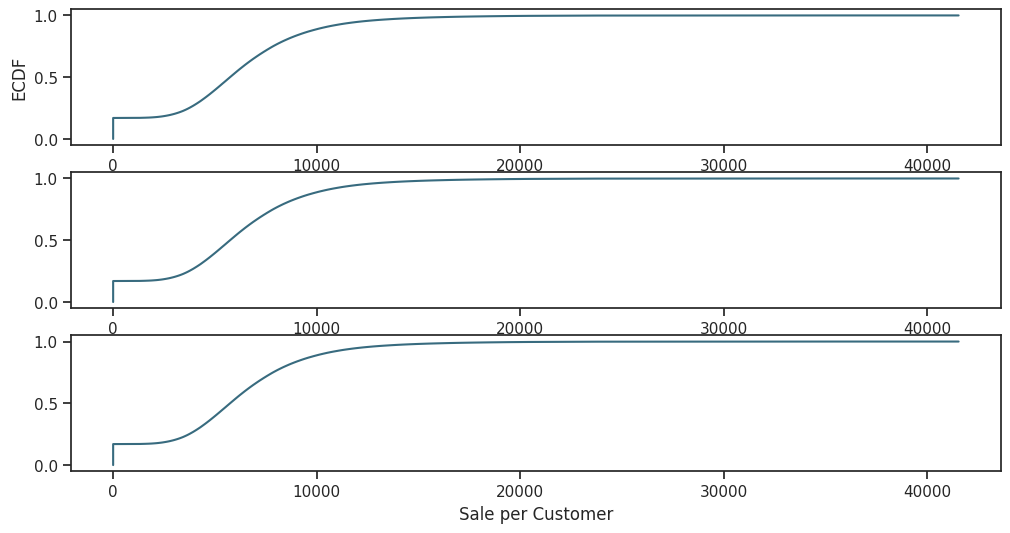

In [9]:
sns.set(style='ticks')
color='#386B7F'
plt.figure(figsize=(12,6))

plt.subplot(311)
cdf = ECDF(train['Sales'])
plt.plot(cdf.x,cdf.y,label = "statmodels",color=color)
plt.xlabel('Sales')
plt.ylabel('ECDF')

plt.subplot(312)
cf = ECDF(train['Customers'])
plt.plot(cdf.x,cdf.y,label = "statmodels",color=color)
plt.xlabel('Customers')

plt.subplot(313)
cf = ECDF(train['SalePerCustomer'])
plt.plot(cdf.x,cdf.y,label = "statmodels",color=color)
plt.xlabel('Sale per Customer')

### Missing values

In [10]:
# cloased stores
closed_stores=train[(train.Open == 0)&(train.Sales == 0)]
closed_stores.shape

(172817, 13)

There're 172817 closed stores in the data. It is about 10% of the total amount of observations. To avoid any biased forecasts we will drop these values.

In [11]:
# opened stores with zero sales
zero_sales = train[(train.Open !=0)&(train.Sales==0)]
print('Total Zero Sales',zero_sales.shape)
zero_sales.head()

Total Zero Sales (54, 13)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,
2015-05-15,971,5,0,0,1,0,0,1,2015,5,15,20,NaN
2015-03-26,674,4,0,0,1,0,0,0,2015,3,26,13,NaN
2015-02-05,699,4,0,0,1,1,0,0,2015,2,5,6,NaN
2014-10-01,708,3,0,0,1,1,0,0,2014,10,1,40,NaN
2014-09-22,357,1,0,0,1,0,0,0,2014,9,22,39,NaN


In [12]:
train[(train["Open"] != 0) & (train['Sales'] != 0)].shape

(844338, 13)

In [13]:
print("Closed stores and days which didn't have any sales won't be counted into the forecasts.")
train = train[(train["Open"] != 0) & (train['Sales'] != 0)]

print("In total: ", train.shape)

Closed stores and days which didn't have any sales won't be counted into the forecasts.
In total:  (844338, 13)


In [14]:
# additional information about the stores
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


- Store: a unique Id for each store
- StoreType: differentiates between 4 different store models: a, b, c, d
- Assortment: describes an assortment level: a = basic, b = extra, c = extended
- CompetitionDistance: distance in meters to the nearest competitor store
- CompetitionOpenSince[Month/Year]: gives the approximate year and month of the time the - -nearest competitor was opened
- Promo2: Promo2 is a continuing a promotion for some stores: 0 = store is not participating, 1 = store is participating
- Promo2Since[Year/Week]: describes the year and calendar week when the store started participating in Promo2
- PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

In [15]:
#missing values?
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [16]:
# missing values in CompetitionDistance
store[pd.isnull(store.CompetitionDistance)]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Apperently this information is simply missing from the data. No particular pattern observed. In this case, it makes a complete sense to replace NaN with the median values (which is twice less that the average).

In [17]:
# fill NaN with a median value (skewed distribuion)
store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace = True)

In [18]:
# no promo = no information about the promo?
_ = store[pd.isnull(store.Promo2SinceWeek)]
_[_.Promo2!=0].shape

(0, 10)

No, if there's no Promo2 then there's no information about it. We can replace these values by zeros. The same goes for tha variables deducted from the competition, CompetitionOpenSinceMonth and CompetitionOpenSinceYear.

In [19]:
# replace NA's by 0
store.fillna(0,inplace=True)

In [20]:
print("Joining train set with an additional store information.")

Joining train set with an additional store information.


In [21]:
# by specifying inner join we make sure that only those observations 
# that are present in both train and store sets are merged together

train_store = pd.merge(train, store, how='inner',on='Store')
print(train_store.shape)
train_store.head()

(844338, 22)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,...,SalePerCustomer,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,5263,555,1,1,0,1,2015,7,...,9.482883,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,6064,625,1,1,0,1,2015,7,...,9.702400,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,8314,821,1,1,0,1,2015,7,...,10.126675,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,13995,1498,1,1,0,1,2015,7,...,9.342457,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,4822,559,1,1,0,1,2015,7,...,8.626118,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


### Store types

In this section we will closely look at different levels of StoreType and how the main metric Sales is distributed among them.

In [22]:
train_store.groupby('StoreType')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457042.0,6925.697986,3277.351589,46.0,4695.25,6285.0,8406.00,41551.0
b,15560.0,10233.380141,5155.729868,1252.0,6345.75,9130.0,13184.25,38722.0
c,112968.0,6933.126425,2896.958579,133.0,4916.00,6408.0,8349.25,31448.0
d,258768.0,6822.300064,2556.401455,538.0,5050.00,6395.0,8123.25,38037.0


StoreType B has the highest average of Sales among all others, however we have much less data for it. So let's print an overall sum of Sales and Customers to see which StoreType is the most selling and crowded one:

In [23]:
train_store.groupby('StoreType')[['Customers','Sales']].sum()

,Customers,Sales
StoreType,,
a,363541431,3165334859
b,31465616,159231395
c,92129705,783221426
d,156904995,1765392943


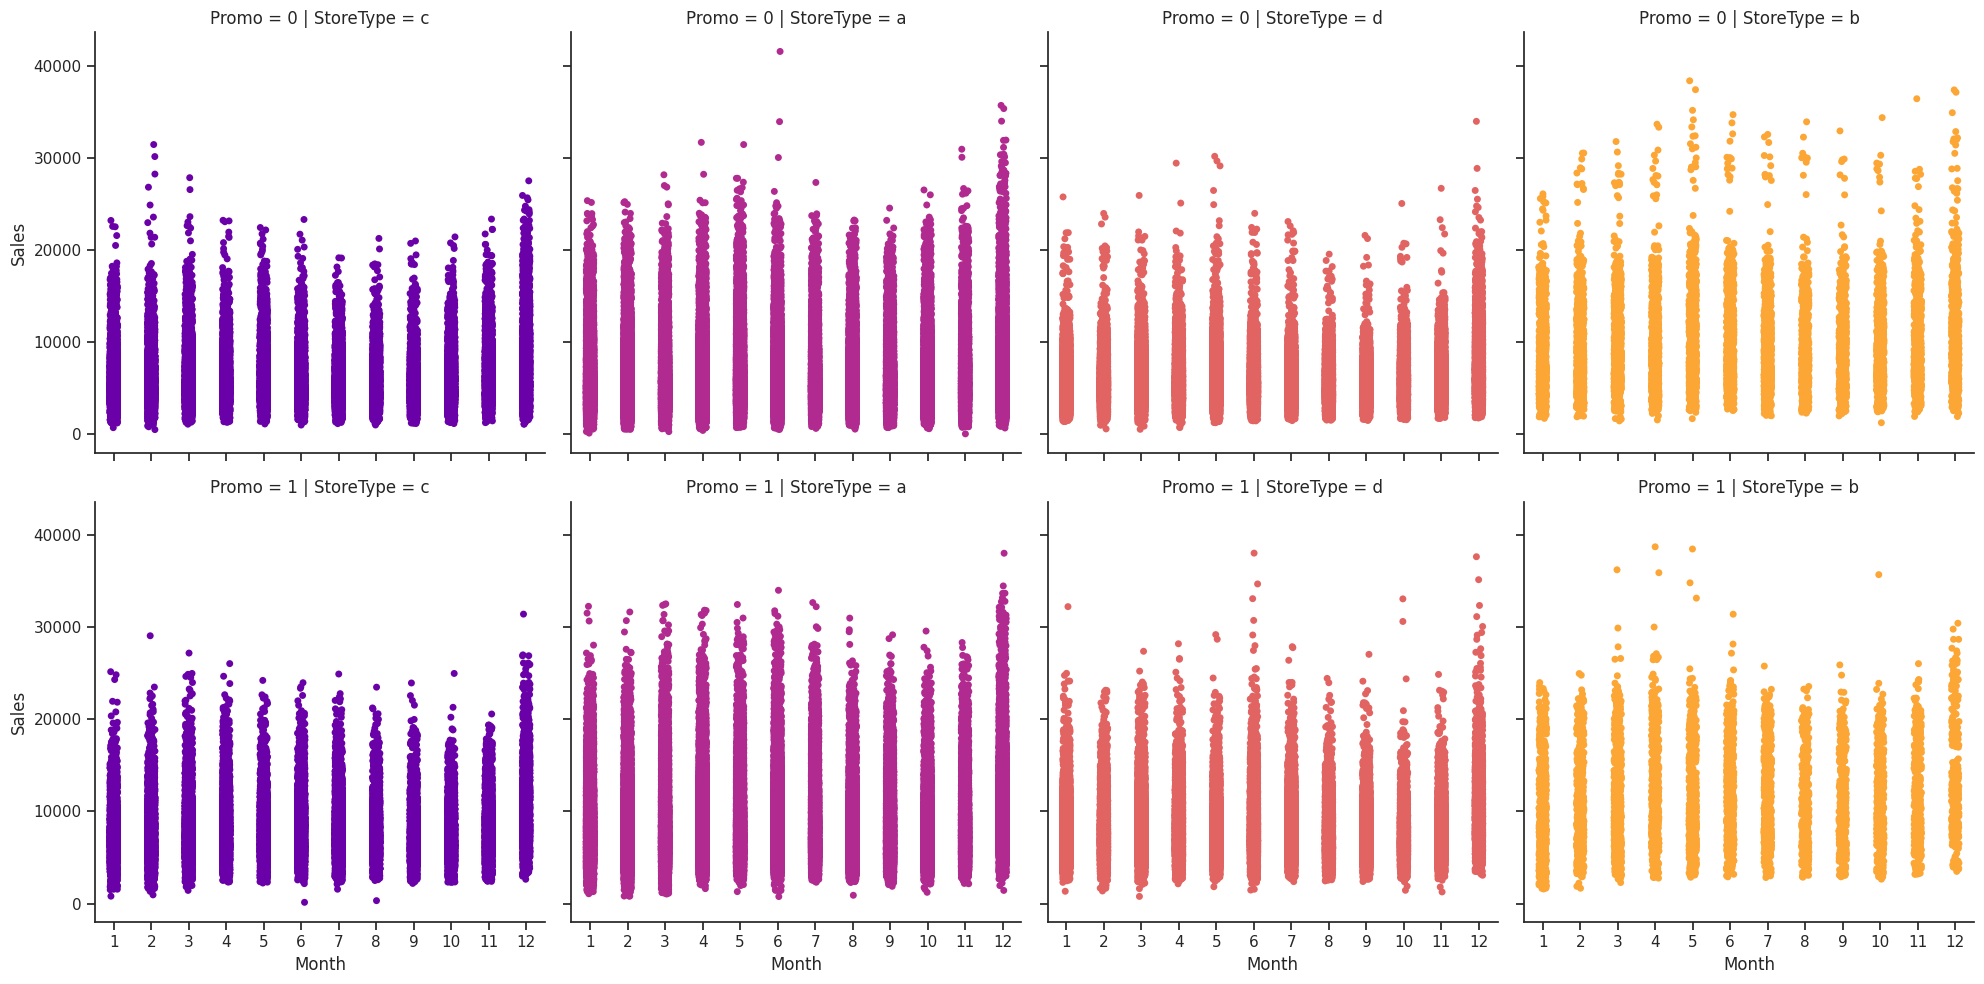

In [24]:
# sales trends
sns.catplot(data=train_store,x='Month',y='Sales',col='StoreType',palette='plasma',
              hue='StoreType',row='Promo',color=color)

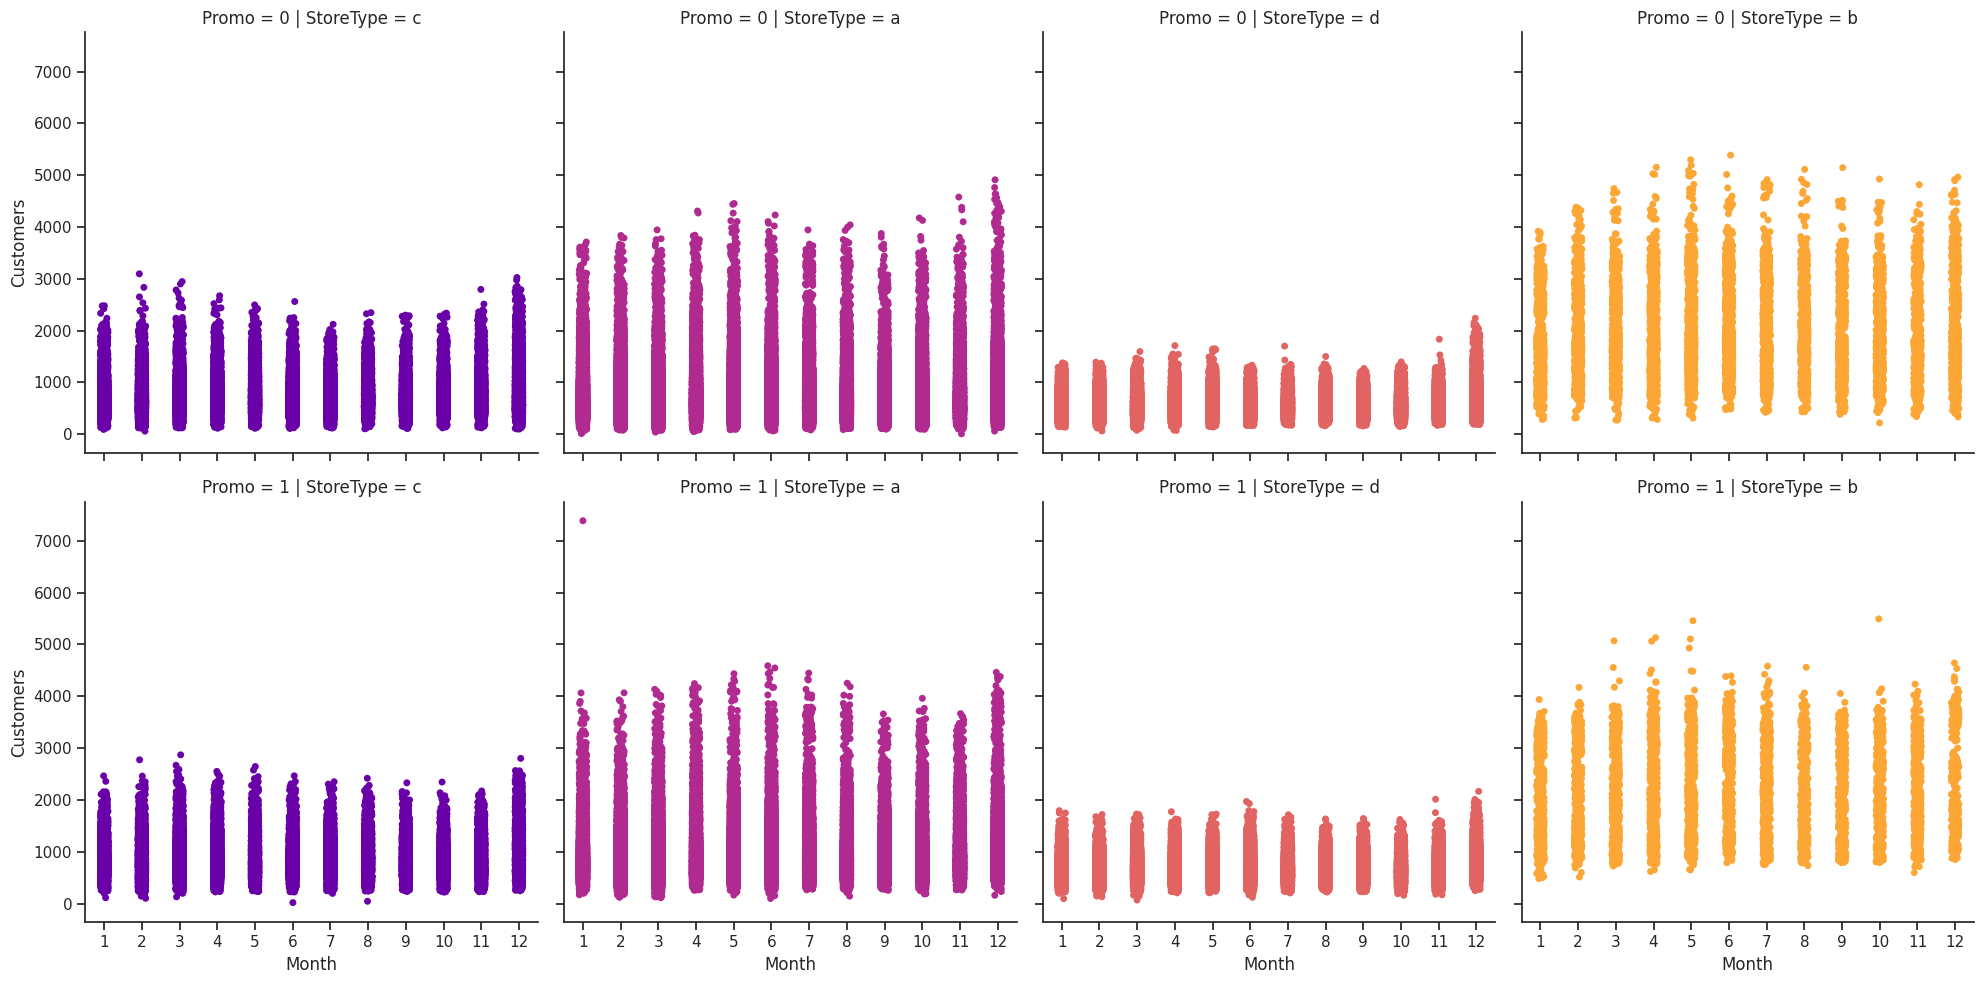

In [25]:
# Customers trends
sns.catplot(data = train_store, x = 'Month', y = "Customers", 
               col = 'StoreType', # per store type in cols
               palette = 'plasma',
               hue = 'StoreType',
               row = 'Promo', # per promo in the store in rows
               color = color) 

All store types follow the same trend but at different scales depending on the presence of the (first) promotion Promo and StoreType itself (case for B).

Already at this point, we can see that Sales escalate towards Christmas holidays. But we'll talk about seasonalities and trends later in the Time Series Analysis section

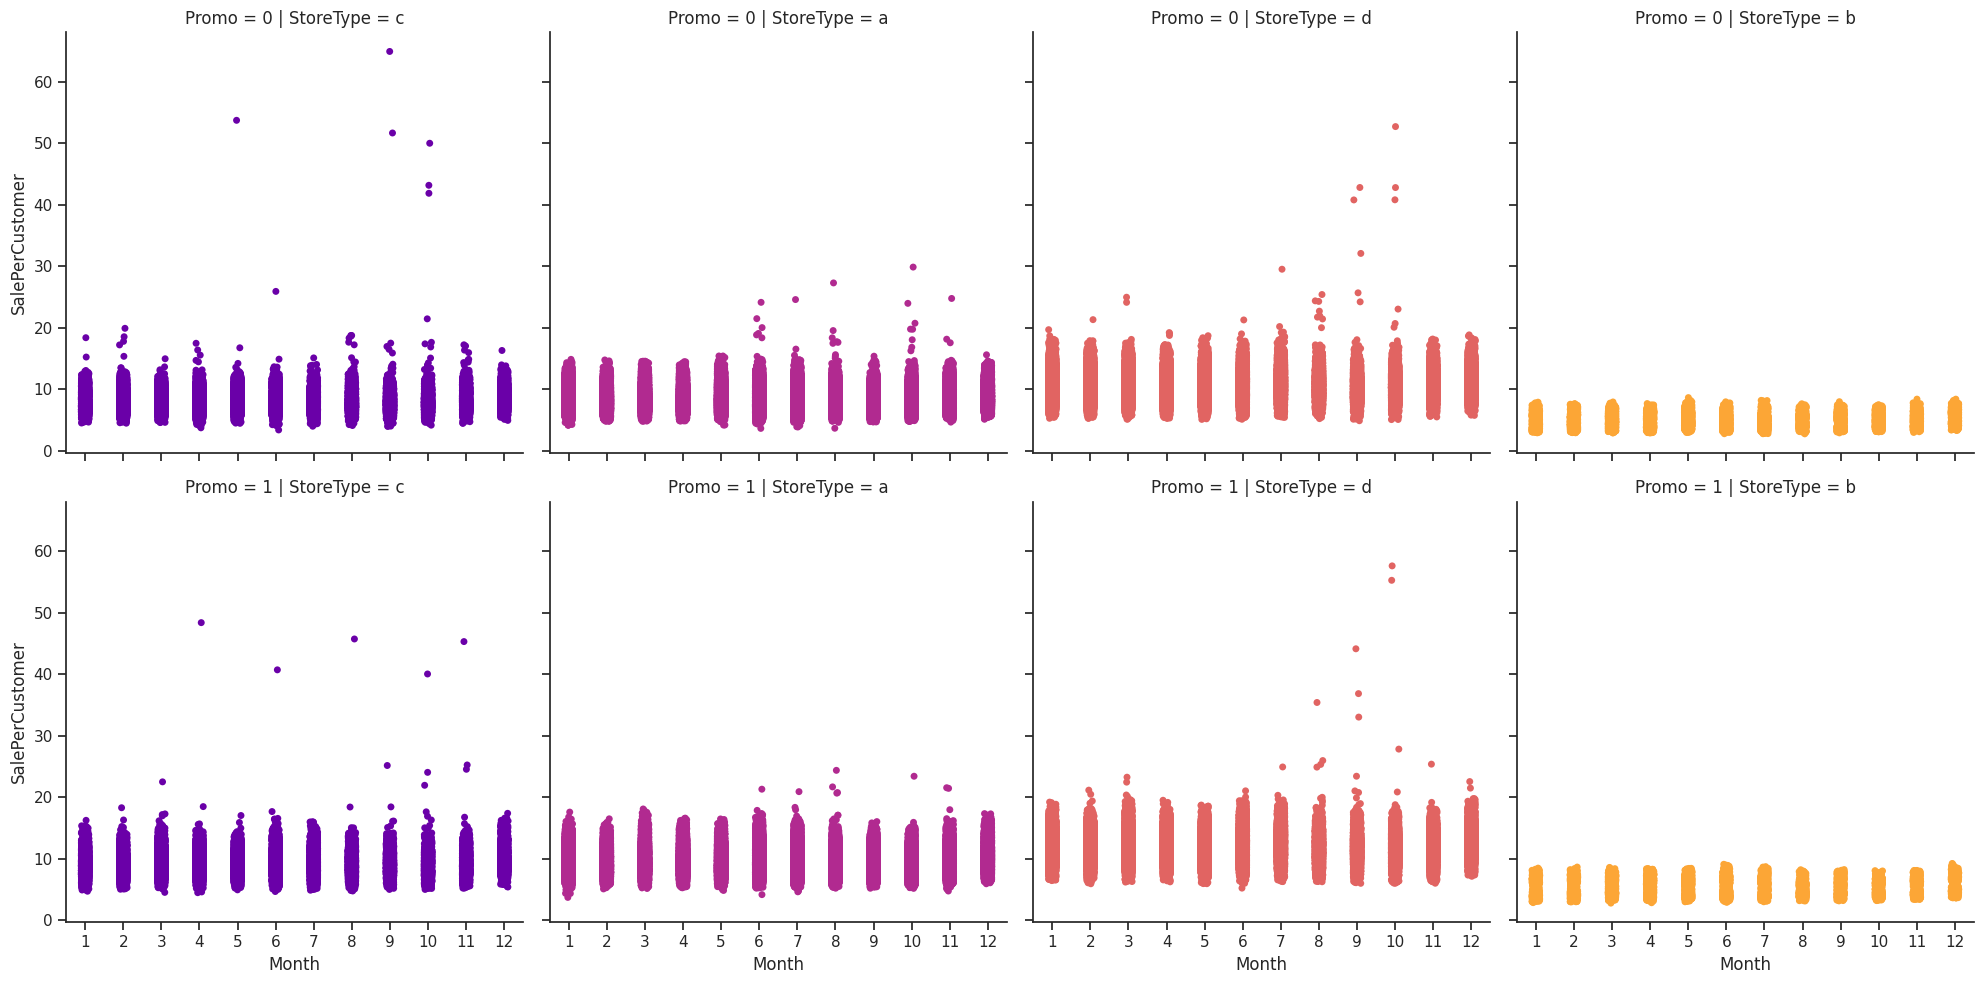

In [26]:
# sale per customer trends
sns.catplot(data = train_store, x = 'Month', y = "SalePerCustomer", 
               col = 'StoreType', # per store type in cols
               palette = 'plasma',
               hue = 'StoreType',
               row = 'Promo', # per promo in the store in rows
               color = color) 

Eventhough the plots above showed StoreType B as the most selling and performant one, in reality it is not true. The highest SalePerCustomer amount is observed at the StoreType D, about 12€ with Promo and 10€ without. As for StoreType A and C it is about 9€.

Low SalePerCustomer amount for StoreType B describes its Buyer Cart: there are a lot of people who shop essentially for "small" things (or in a little quantity). Plus we saw that overall this StoreType generated the least amount of sales and customers over the period.

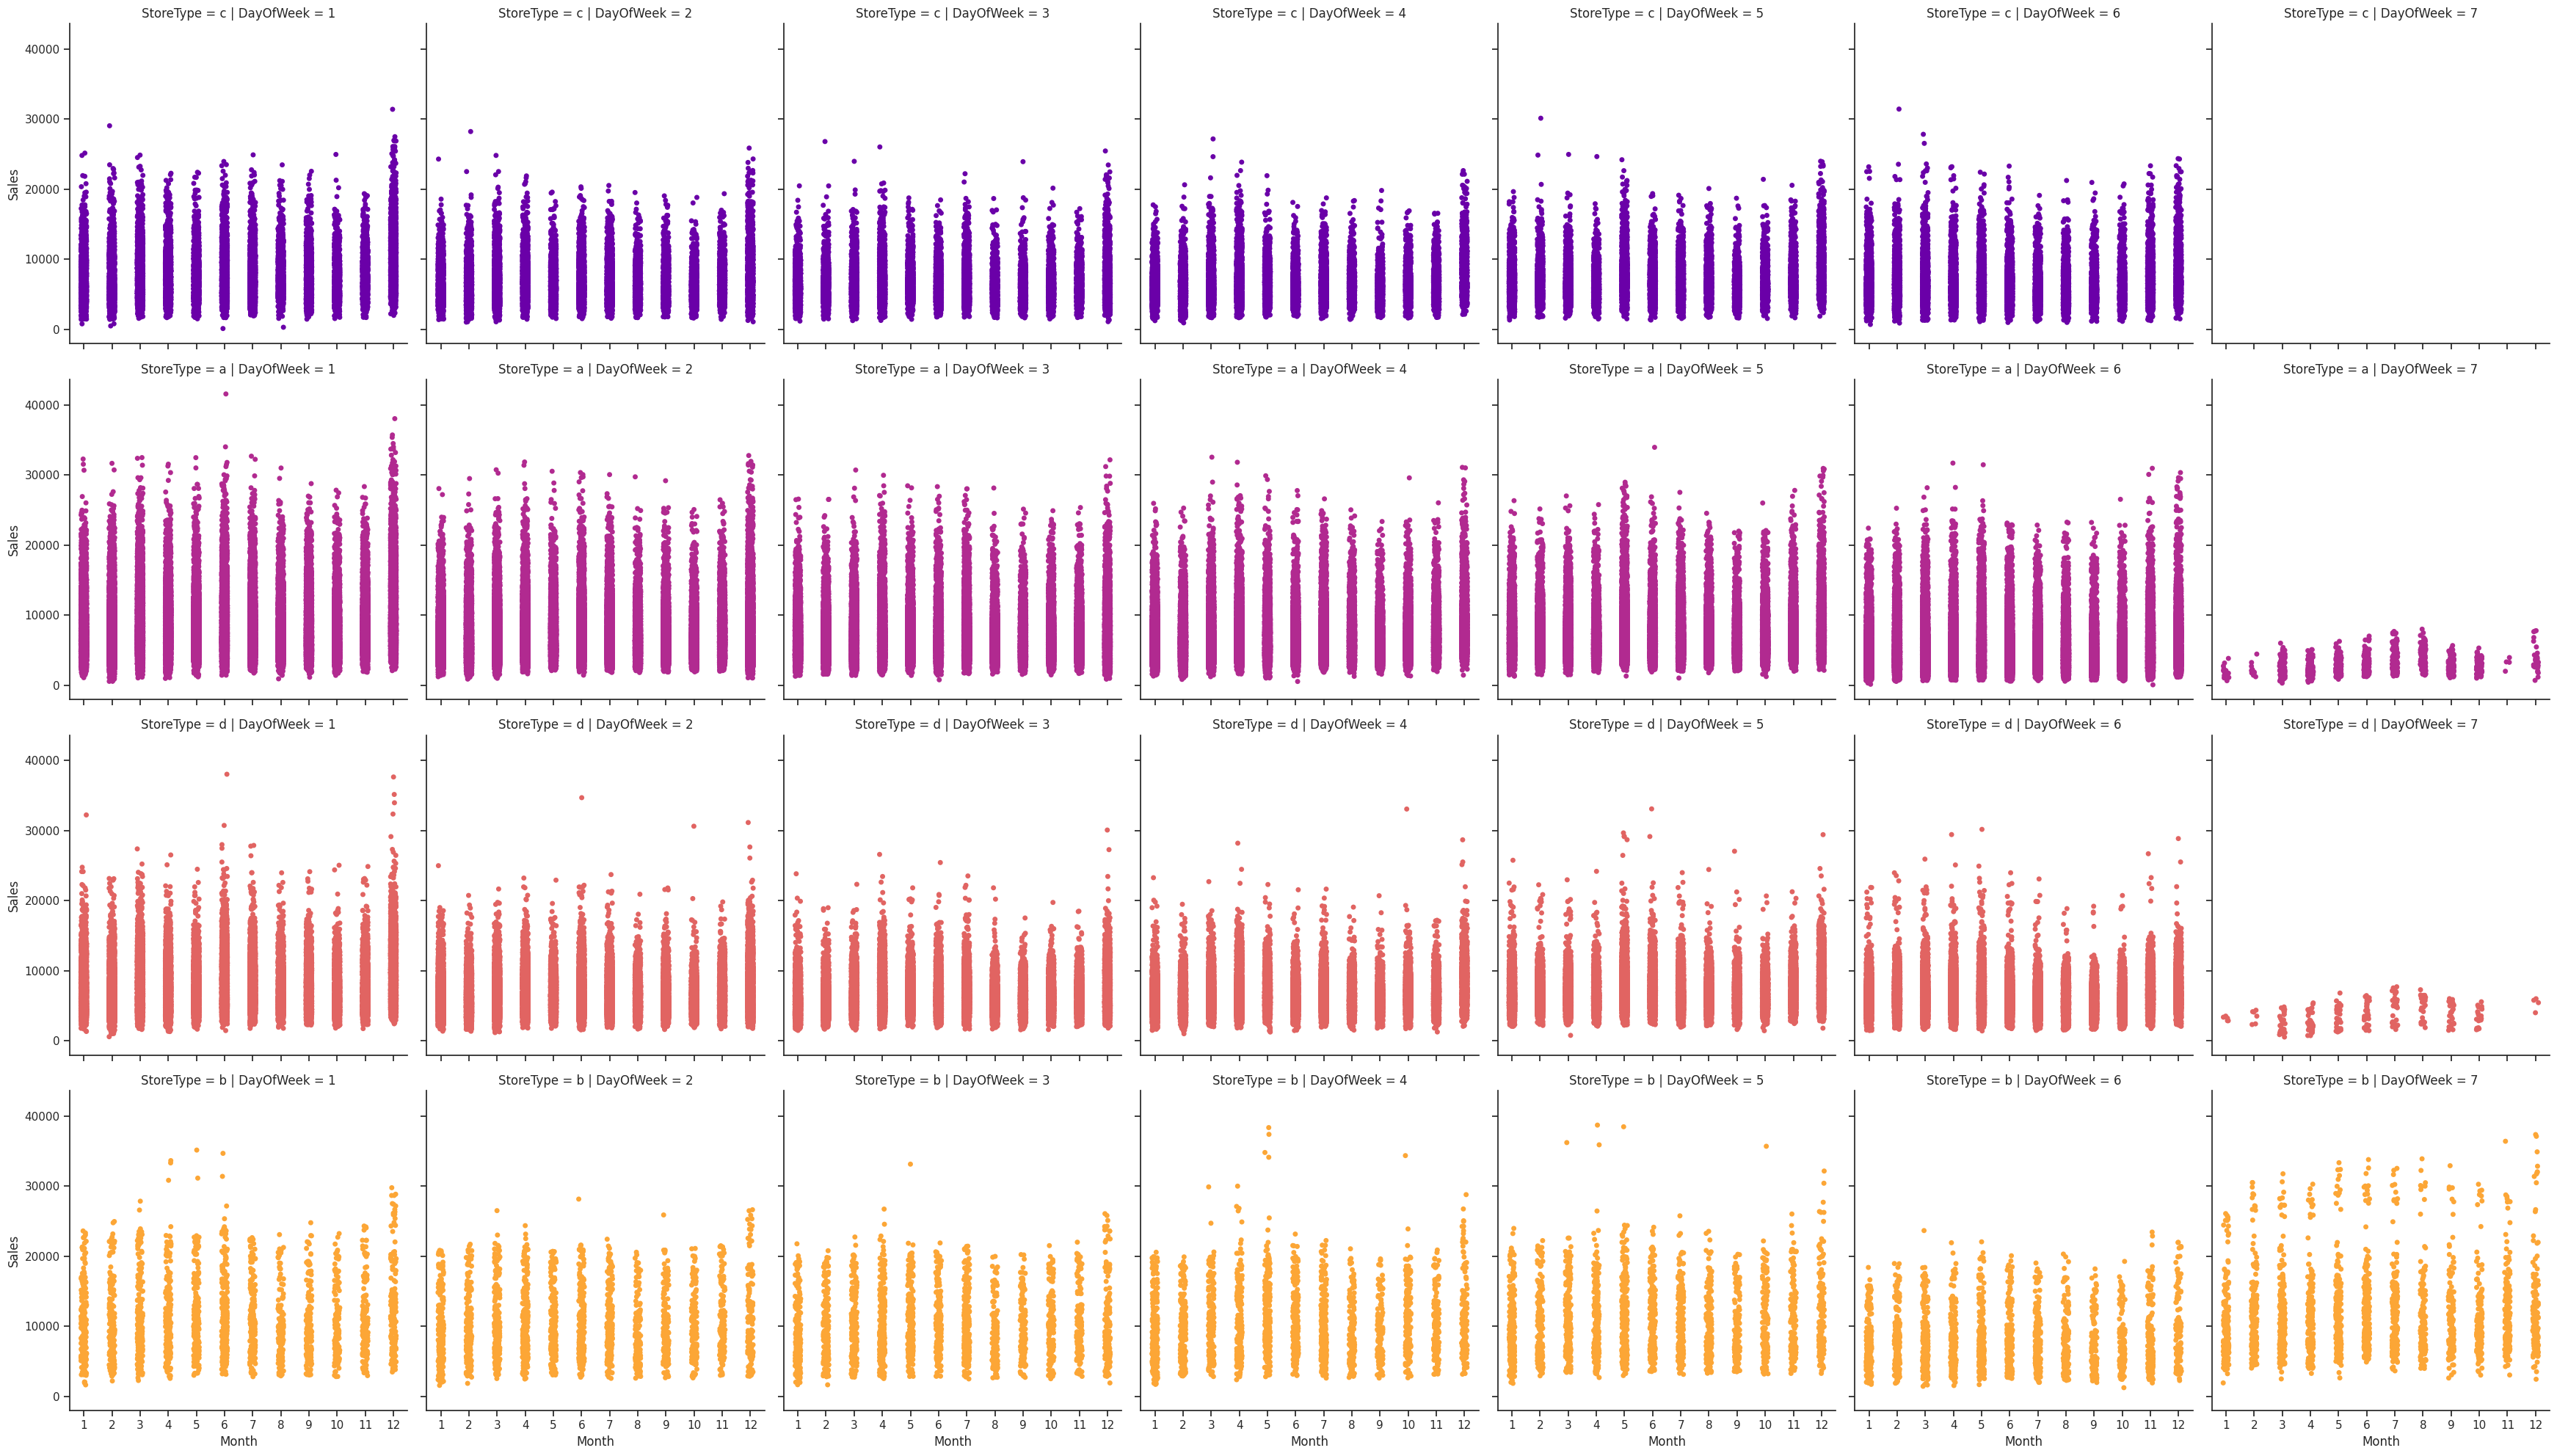

In [27]:
# customers
sns.catplot(data = train_store, x = 'Month', y = "Sales", 
               col = 'DayOfWeek', # per store type in cols
               palette = 'plasma',
               hue = 'StoreType',
               row = 'StoreType', # per store type in rows
               color = color) 

We see that stores of StoreType C are all closed on Sundays, whereas others are most of the time opened. Interestingly enough, stores of StoreType D are closed on Sundays only from October to December.

Bt the way what are the stores which are opened on Sundays?

In [28]:
# stores which are opened on Sundays
train_store[(train_store.Open ==1)&(train_store.DayOfWeek==7)]['Store'].unique()

array([  85,  122,  209,  259,  262,  274,  299,  310,  335,  353,  423,
        433,  453,  494,  512,  524,  530,  562,  578,  676,  682,  732,
        733,  769,  863,  867,  931,  948, 1045, 1081, 1097, 1099,  877])

To complete our preliminary data analysis, we can add variables describing the period of time during which competition and promotion were opened:

In [29]:
# competition open time (in months)
train_store['CompetitionOpen'] = 12*(train_store.Year - train_store.CompetitionOpenSinceYear)+(train_store.Month - train_store.CompetitionOpenSinceMonth)
train_store['CompetitionOpen'].head()

0     82.0
1     92.0
2    103.0
3     70.0
4      3.0
Name: CompetitionOpen, dtype: float64

In [30]:
# Promo open time
train_store['PromoOpen'] = 12 * (train_store.Year - train_store.Promo2SinceYear) + (train_store.WeekOfYear - train_store.Promo2SinceWeek) / 4.0

In [31]:
# replace NA's by 0
train_store.fillna(0, inplace = True)

In [32]:
# average PromoOpen time and CompetitionOpen time per store type
train_store.loc[:, ['StoreType', 'Sales', 'Customers', 'PromoOpen', 'CompetitionOpen']].groupby('StoreType').mean()

,Sales,Customers,PromoOpen,CompetitionOpen
StoreType,,,,
a,6925.697986,795.422370,12918.492198,7115.514452
b,10233.380141,2022.211825,17199.328069,11364.495244
c,6933.126425,815.538073,12158.636107,6745.418694
d,6822.300064,606.353935,10421.916846,9028.526526


The most selling and crowded StoreType A doesn't appear to be the one the most exposed to competitors. Instead it's a StoreType B, which also has the longest running period of promotion.

### Correlational Analysis

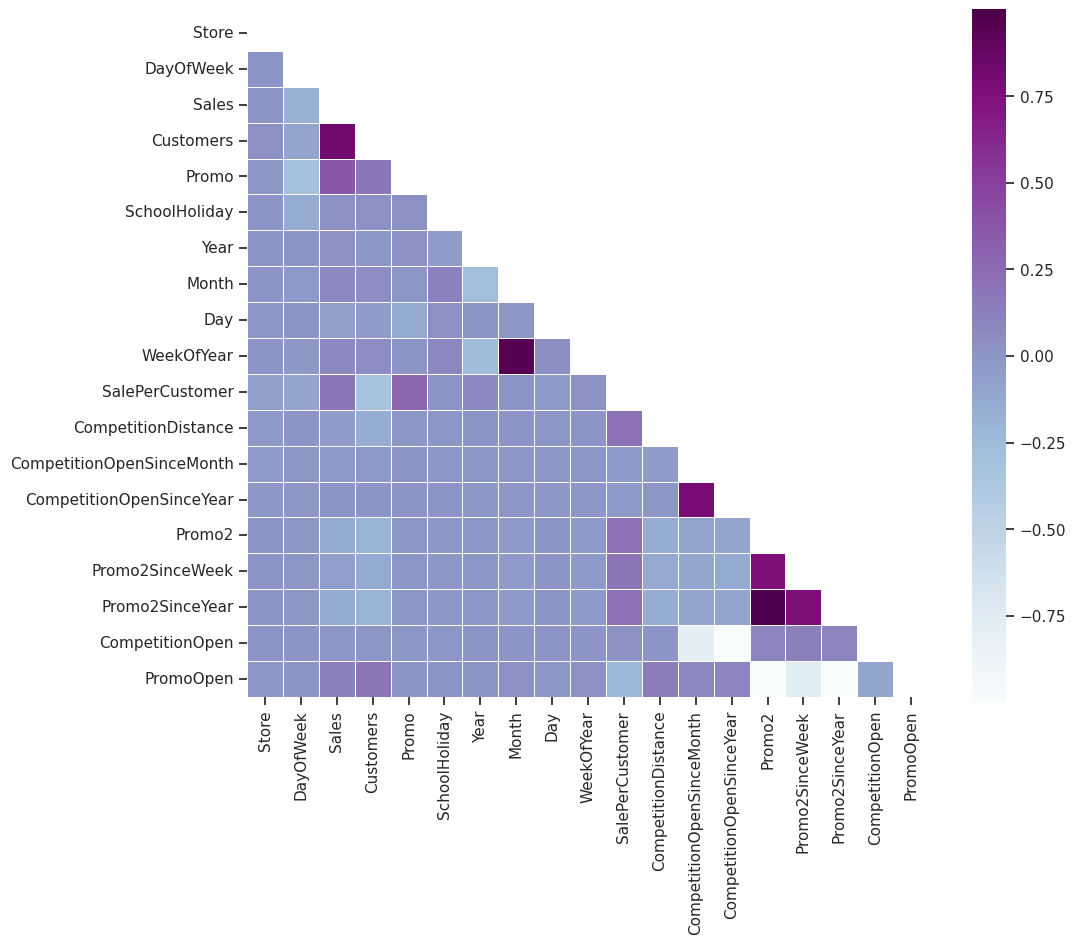

In [33]:
# Compute the correlation matrix
# exclude 'Open' variable
train_store_num = train_store.select_dtypes(include=[np.number])
corr_all = train_store_num.drop('Open',axis=1,errors='ignore').corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr_all, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f,ax = plt.subplots(figsize=(11,9))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_all, mask = mask, square = True, linewidth =.5,ax=ax,cmap="BuPu")
plt.show()

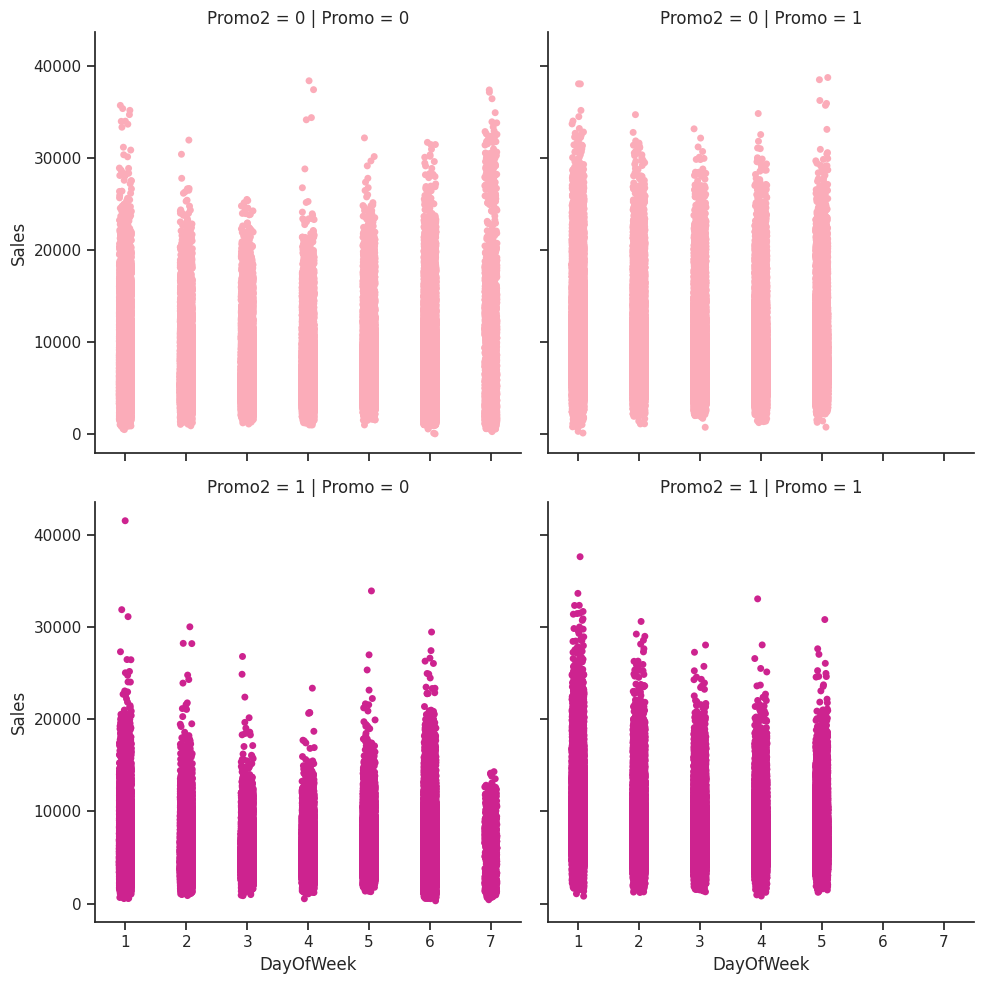

In [34]:
# sale per customer trends

sns.catplot(data= train_store, x = 'DayOfWeek', y = "Sales", col = 'Promo', row='Promo2',
              hue = 'Promo2',palette='RdPu')

In case of no promotion, both Promo and Promo2 are equal to 0, Sales tend to peak on Sunday (!). Though we should note that StoreType C doesn't work on Sundays. So it is mainly data from StoreType A, B and D.
On the contrary, stores that run the promotion tend to make most of the Sales on Monday. This fact could be a good indicator for Rossmann marketing campaigns. The same trend follow the stores which have both promotion at the same time (Promo and Promo2 are equal to 1).
Promo2 alone doesn't seem to be correlated to any significant change in the Sales amount. This can be also prooved by the blue pale area on the heatmap above.

### Time-Series Analysis per Store Type

What makes a time series different from a regular regression problem?

It is time dependent. The basic assumption of a linear regression that the observations are independent doesn’t hold in this case.
Along with an increasing or decreasing trend, most time series have some form of seasonality trends, i.e. variations specific to a particular time frame. For example, for Christmas holidays, which we will see in this dataset.
We build a time series analysis on store types instead of individual stores. The main advantage of this approach is its simplicity of presentation and overall account for different trends and seasonalities in the dataset.

In this section, we will analyse time series data: its trends, sesonalities and autocorrelation. Usually at the end of the analysis, we are able to develop a seasonal ARIMA (Autoregression Integrated Moving Average) model but it won't be our main focus today. Instead, we try to understand the data, and only later come up with the forecasts using Prophet methodology.

### Seasonality

We take four stores from store types to represent their group:¶
Store number 2 for StoreType A
Store number 85 for StoreType B,
Store number 1 for StoreType C
Store number 13 for StoreType D.
It also makes sense to downsample the data from days to weeks using the resample method to see the present trends more clearly.

<Axes: xlabel='Date'>

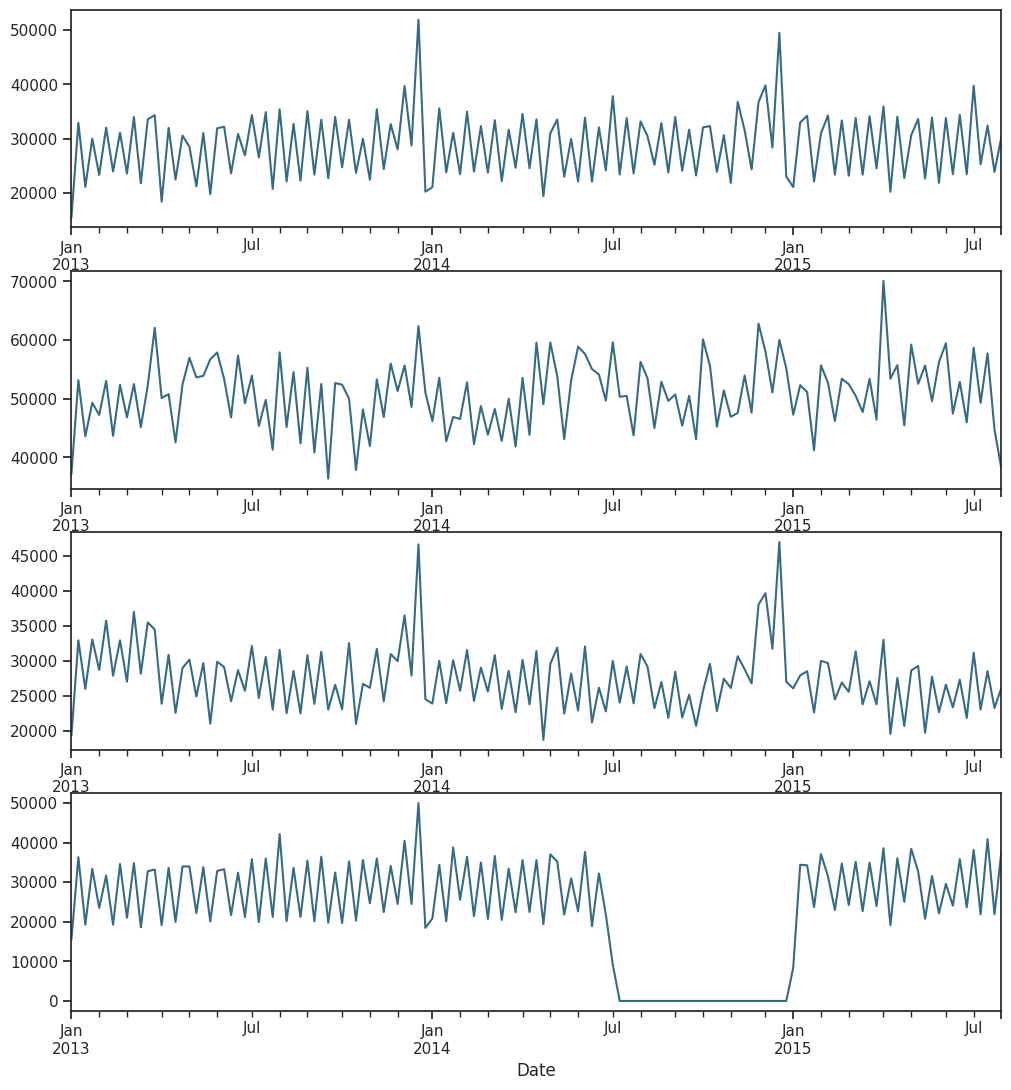

In [35]:
train['Sales'] = train['Sales']*1.0

sales_a = train[train.Store==2]['Sales']
sales_b = train[train.Store==85]['Sales'].sort_index(ascending=True)
sales_c = train[train.Store == 1]['Sales']
sales_d = train[train.Store==13]['Sales']

f,(ax1,ax2,ax3,ax4) = plt.subplots(4,figsize=(12,13))

sales_a.resample('W').sum().plot(color=color,ax=ax1)
sales_b.resample('W').sum().plot(color = color, ax = ax2)
sales_c.resample('W').sum().plot(color = color, ax = ax3)
sales_d.resample('W').sum().plot(color = color, ax = ax4)

### Yearly trend

<Axes: xlabel='Date'>

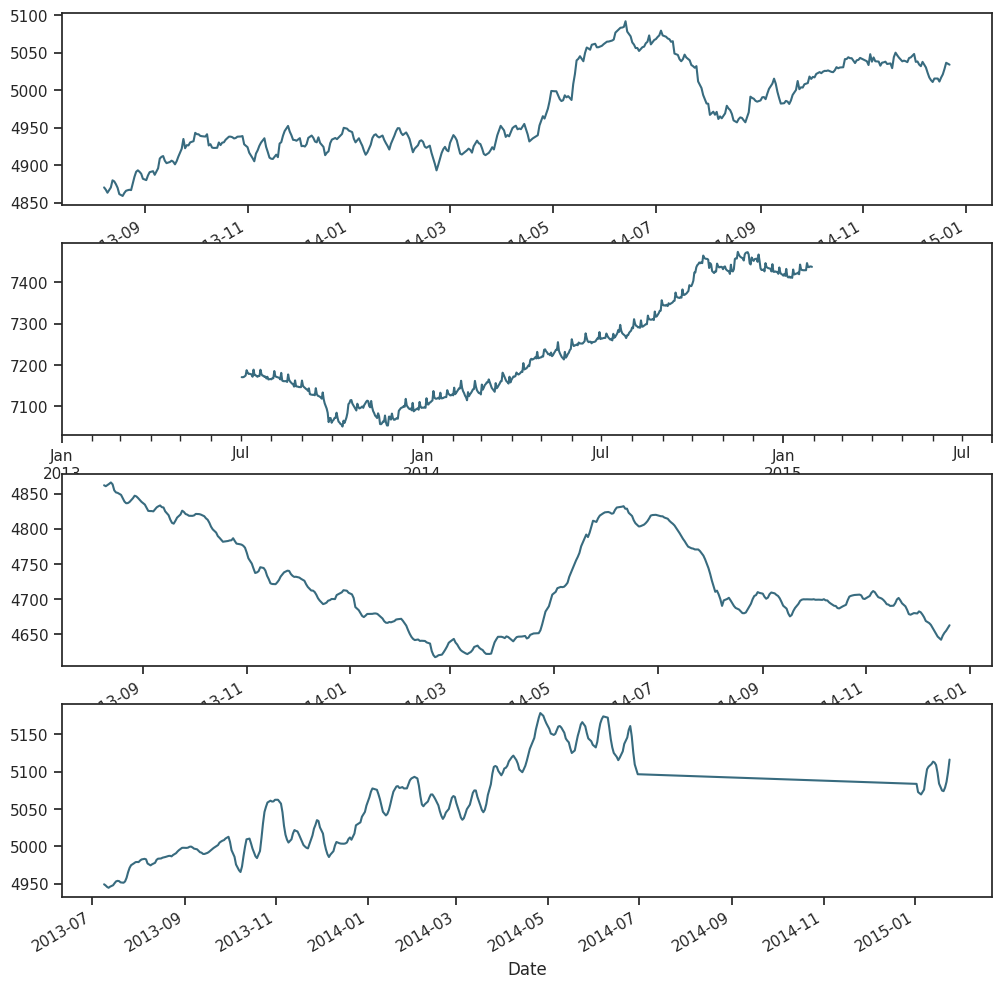

In [36]:
f, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize = (12, 13))

decomposition_a = seasonal_decompose(sales_a, model = 'additive', period = 365)
decomposition_a.trend.plot(color=color, ax = ax1)

decomposition_b = seasonal_decompose(sales_b, model = 'additive', period = 365)
decomposition_b.trend.plot(color = color, ax = ax2)

decomposition_c = seasonal_decompose(sales_c, model = 'additive', period = 365)
decomposition_c.trend.plot(color = color, ax = ax3)

decomposition_d = seasonal_decompose(sales_d, model = 'additive', period = 310)
decomposition_d.trend.plot(color = color, ax = ax4)

Overall sales seems to increase, however not for the StoreType C (a third from the top). Eventhough the StoreType A is the most selling store type in the dataset, it seems that it cab follow the same decresing trajectory as StoreType C did.

### Autocorrelaion

The next step in ourtime series analysis is to review Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots.

ACF is a measure of the correlation between the timeseries with a lagged version of itself. For instance at lag 5, ACF would compare series at time instant ‘t1’…’tn’ with series at instant ‘t1-5’…’tn-5’ (t1-5 and tn being end points).

PACF, on the other hand, measures the correlation between the timeseries with a lagged version of itself but after eliminating the variations explained by the intervening comparisons. Eg. at lag 5, it will check the correlation but remove the effects already explained by lags 1 to 4.

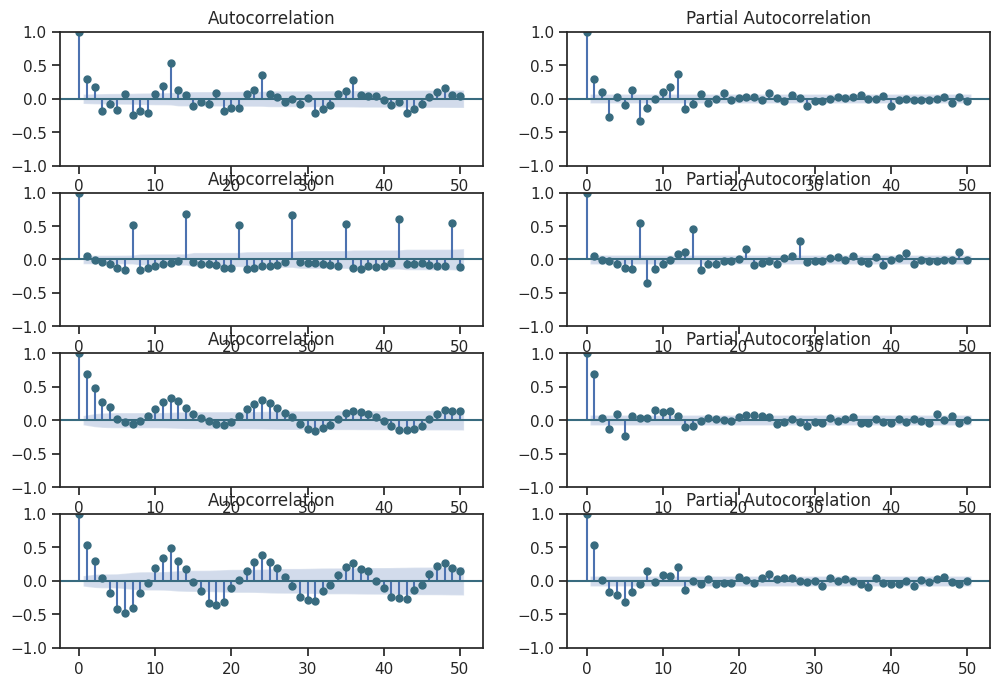

In [37]:
plt.figure(figsize=(12,8))

plt.subplot(421);plot_acf(sales_a,lags=50,ax=plt.gca(),color=color)
plt.subplot(422);plot_pacf(sales_a, lags=50, ax = plt.gca(), color=color)

plt.subplot(423);plot_acf(sales_b, lags=50,ax=plt.gca(),color=color)
plt.subplot(424);plot_pacf(sales_b, lags=50, ax=plt.gca(), color = color)

plt.subplot(425);plot_acf(sales_c, lags=50,ax=plt.gca(),color=color)
plt.subplot(426);plot_pacf(sales_c, lags=50, ax=plt.gca(), color = color)

plt.subplot(427);plot_acf(sales_d, lags=50,ax=plt.gca(),color=color)
plt.subplot(428);plot_pacf(sales_d, lags=50, ax=plt.gca(), color = color)

plt.show()

We can read these plots horizontally. Each horizontal pair is for one 'StoreType', from A to D. In general, those plots are showing the correlation of the series with itself, lagged by x time units correlation of the series with itself, lagged by x time units.

There is at two things common for each pair of plots: non randomnes of the time series and high lag-1 (which will probably need a higher order of differencing d/D).

Type A and type B: Both types show seasonalities at certain lags. For type A, it is each 12th observation with positives spikes at the 12 (s) and 24(2s) lags and so on. For type B it's a weekly trend with positives spikes at the 7(s), 14(2s), 21(3s) and 28(4s) lags.
Type C and type D: Plots of these two types are more complex. It seems like each observation is coorrelated to its adjacent observations.

### Time Series Analysis and Forecasting with Prophet


#### Forecasting for the next 6 weeks for the first store

In [38]:
df = pd.read_csv("/kaggle/input/rossmann-store-sales/train.csv",low_memory=False)

df= df[(df["Open"]!=0)&(df['Sales']!=0)]

sales = df[df.Store==1].loc[:,['Date','Sales']]

sales = sales.sort_index(ascending = False)

sales['Date'] = pd.DatetimeIndex(sales['Date'])

sales.dtypes

Date     datetime64[ns]
Sales             int64
dtype: object

In [39]:
sales = sales.rename(columns = {'Date':'ds','Sales':'y'})
sales.head()

,ds,y
1014980,2013-01-02,5530
1013865,2013-01-03,4327
1012750,2013-01-04,4486
1011635,2013-01-05,4997
1009405,2013-01-07,7176


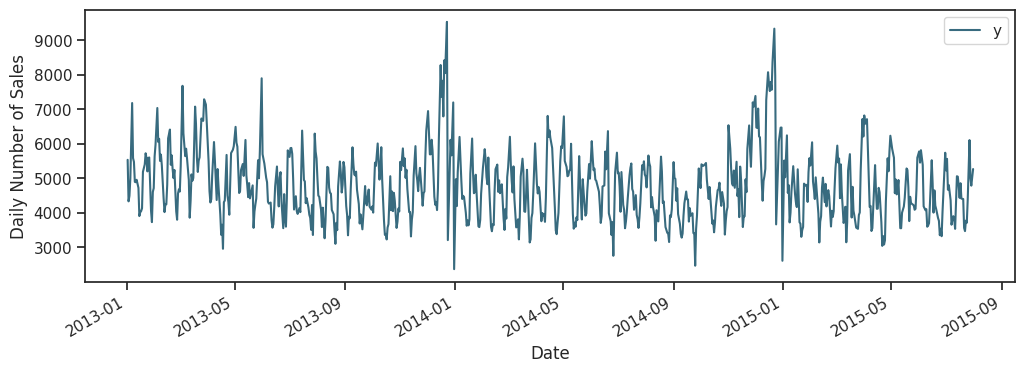

In [40]:
#plot daily sales

ax = sales.set_index('ds').plot(figsize = (12,4), color = color)
ax.set_ylabel('Daily Number of Sales')
ax.set_xlabel('Date')
plt.show()

### Modeling Holidays


Prophet also allows to model for holidays, and that's what we do here.

The StateHoliday variable in the dataset indicates a state holiday, at which all stores are normally closed. There are also school holidays in the dataset at which ceratin stores are also closing their doors.

In [41]:
state_dates = df[(df.StateHoliday == 'a')|(df.StateHoliday == 'b')&(df.StateHoliday=='c')].loc[:,'Date'].values

school_dates = df[df.SchoolHoliday == 1].loc[:,'Date'].values

state = pd.DataFrame({'holiday':'state_holiday',
                     'ds':pd.to_datetime(state_dates)})
school = pd.DataFrame({'holiday':'school_holiday',
                      'ds':pd.to_datetime(school_dates)})

holidays = pd.concat((state,school))
holidays.head()

,holiday,ds
0,state_holiday,2015-06-04
1,state_holiday,2015-06-04
2,state_holiday,2015-06-04
3,state_holiday,2015-06-04
4,state_holiday,2015-06-04


In [42]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = Prophet(interval_width = 0.95, holidays = holidays)
my_model.fit(sales)

future_dates = my_model.make_future_dataframe(periods = 6*7)

future_dates.tail(7)

10:36:33 - cmdstanpy - INFO - Chain [1] start processing
10:36:33 - cmdstanpy - INFO - Chain [1] done processing


,ds
816,2015-09-05
817,2015-09-06
818,2015-09-07
819,2015-09-08
820,2015-09-09
821,2015-09-10
822,2015-09-11


In [43]:
# predictions
forecast = my_model.predict(future_dates)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2013-01-02,5517.668778,3991.601724,7195.081629
1,2013-01-03,5307.688890,3719.658782,6949.374554
2,2013-01-04,5445.624420,3878.655667,7078.638998
3,2013-01-05,5741.536844,3996.139035,7229.019832
4,2013-01-07,5663.077567,4003.948856,7296.630458
...,...,...,...,...
818,2015-09-07,4176.629055,2613.806192,5901.547782
819,2015-09-08,3679.150643,2111.257715,5466.531407
820,2015-09-09,3565.375100,1963.010605,5199.496199
821,2015-09-10,3477.635789,1836.527070,5232.696475
